Title: PSL_Anomaly_bc.ipynb

Purpose: Calculate the anomaly for CMIP6 and ERA5 psl data

Author: Onno Nennecke on 02.06.2025 Modified: 19.06.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import re
import glob
import time

# Importing functions
import Functions.grid_func as grid_func
# import Functions.winter_date_func as winter_date_func


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


In [2]:
def setup_gridlines(ax, deg = 20, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

In [4]:
ts_mean_psl_pm = xr.open_dataset('/climca/people/onennecke/model_output/var_means/psl_bc/psl_mean_combined.nc')
ts_mean_psl_pm.ESM

<xarray.DataArray 'ESM' (ESM: 12)> Size: 624B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
    crs       int64 8B ...
    gridtype  <U6 24B ...
  * ESM       (ESM) <U13 624B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'

### Define used models

In [5]:
# Read the dataframe from the csv file
used_runs = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs.csv')

# Change the ref column to 1 for the first instance of each model
used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

used_runs

,ESM,Institution,run,Ref
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1,1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1,0
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1,0
3,BCC-CSM2-MR,BCC,r1i1p1f1,1
4,CESM2,NCAR,r4i1p1f1,1
...,...,...,...,...
94,UKESM1-0-LL,MOHC,r3i1p1f2,0
95,UKESM1-0-LL,MOHC,r8i1p1f2,0
96,UKESM1-0-LL,NIMS-KMA,r15i1p1f2,1
97,UKESM1-0-LL,NIMS-KMA,r13i1p1f2,0


In [ ]:
for i in range(len(used_runs)):
    run_time = time.time()
    ESM = used_runs['ESM'][i]
    Inst = used_runs['Institution'][i]
    run = used_runs['run'][i]
    print(f'Processing Run Nr. {i+1}, {ESM}, {Inst}, {run}, \n')
    base_path = '/climca/people/onennecke/debiased_data/'
    sel_run = glob.glob(os.path.join(f"/climca/people/onennecke/debiased_data/{ESM}_{run}_psl_debiased.nc"))

    nc = xr.open_mfdataset(sel_run)
    # Filter to only winter months (October to March)
    nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    psl_anomaly = nc.copy()
    # Calculate anomaly
    psl_anomaly['psl'] = nc['psl'] - ts_mean_psl_pm.sel(ESM = ESM)['psl']



    ts_output = psl_anomaly.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    ts_output.load()
    ts_output.to_netcdf(f'/climca/people/onennecke/model_output/psl_anomaly/bc/{ESM}_{run}_psl_anomaly.nc')
    # break
ts_output

Processing Run Nr. 1, ACCESS-CM2, CSIRO-ARCCSS, r4i1p1f1, 

Processing Run Nr. 2, ACCESS-CM2, CSIRO-ARCCSS, r5i1p1f1, 

Processing Run Nr. 3, ACCESS-CM2, CSIRO-ARCCSS, r1i1p1f1, 

Processing Run Nr. 4, BCC-CSM2-MR, BCC, r1i1p1f1, 

Processing Run Nr. 5, CESM2, NCAR, r4i1p1f1, 

Processing Run Nr. 6, CESM2, NCAR, r10i1p1f1, 

Processing Run Nr. 7, CESM2, NCAR, r11i1p1f1, 

Processing Run Nr. 8, EC-Earth3, EC-Earth-Consortium, r149i1p1f1, 

Processing Run Nr. 9, EC-Earth3, EC-Earth-Consortium, r4i1p1f1, 

Processing Run Nr. 10, EC-Earth3, EC-Earth-Consortium, r148i1p1f1, 

Processing Run Nr. 11, EC-Earth3, EC-Earth-Consortium, r105i1p1f1, 

Processing Run Nr. 12, EC-Earth3, EC-Earth-Consortium, r134i1p1f1, 

Processing Run Nr. 13, EC-Earth3, EC-Earth-Consortium, r141i1p1f1, 

Processing Run Nr. 14, EC-Earth3, EC-Earth-Consortium, r146i1p1f1, 

Processing Run Nr. 15, EC-Earth3, EC-Earth-Consortium, r112i1p1f1, 

Processing Run Nr. 16, EC-Earth3, EC-Earth-Consortium, r117i1p1f1, 

Processi

<xarray.Dataset> Size: 15MB
Dimensions:   (time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U11 44B 'UKESM1-0-LL'
    run       <U9 36B 'r14i1p1f2'
    ESM_run   <U21 84B 'UKESM1-0-LL_r14i1p1f2'
Data variables:
    psl       (time, lat, lon) float32 15MB 844.8 881.2 ... -1.659e+03
Attributes:
    regrid_method:  bilinear

### Same for ERA5

In [14]:
variable = 'slp'
# Select all files in the range 2014-2024
path = f'/climca/data/ERA5/daily/{variable}/'
year_range = (2015, 2024)
all_files = sorted(glob.glob(os.path.join(path, '*.nc')))

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

# filtered_files

In [15]:
def preprocess_ERA5(ds, s = 25, n = 75, w = 335, e = 35):
    ds = ds.reindex(lat=ds.lat[::-1])
    if e < w:
        part1 = ds.sel(lon=slice(w, 360))
        part2 = ds.sel(lon=slice(0, e))
        europe = xr.concat([part1, part2], dim="lon")
        ds = europe.sel(lat=slice(s, n))
    else:
        ds = ds.sel(lat=slice(s, n), lon=slice(w, e))
    return ds

In [21]:
ds = xr.open_mfdataset(filtered_files, combine='by_coords', preprocess=preprocess_ERA5)
# Keep only the desired variable, but retain Dataset structure
ds = ds[['var151']]

# Filter to only winter months (October to March)
ds = ds.sel(time=ds.time.dt.month.isin([10, 11, 12, 1, 2, 3]))

# Regrid the dataset
regridded_ds = grid_func.regrid(ds, s = 30, n = 70, w = 340, e = 30)


# Rename the variable to 'pls'
regridded_ds = regridded_ds.rename({'var151': 'psl'})

# Calculate anomaly
regridded_ds['psl'] = regridded_ds['psl'] - ts_mean_psl_pm.sel(ESM = 'ERA5')['psl']
# Assign coordinates for ESM
regridded_ds =  regridded_ds.assign_coords(run = 'hist', ESM = 'ERA5', ESM_run = 'ERA5_hist')

ERA5_output = regridded_ds.where(~((regridded_ds['time.month'] == 2) & (regridded_ds['time.day'] == 29)), drop=True)
# Change the time to 00:00:00
ERA5_output['time'] = ERA5_output['time'].dt.floor('D')

ERA5_output
# Save the dataset
ERA5_output.to_netcdf(f'/climca/people/onennecke/model_output/psl_anomaly/bc/ERA5_hist_psl_anomaly.nc')


In [22]:
ERA5_output

<xarray.Dataset> Size: 15MB
Dimensions:   (time: 1820, lat: 40, lon: 50)
Coordinates:
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
    ESM       <U4 16B 'ERA5'
    run       <U4 16B 'hist'
    ESM_run   <U9 36B 'ERA5_hist'
Data variables:
    psl       (time, lat, lon) float32 15MB dask.array<chunksize=(1, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### Load data again

In [23]:
path = '/climca/people/onennecke/model_output/psl_anomaly/bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 1GB
Dimensions:   (ESM_run: 100, time: 1820, lat: 40, lon: 50)
Coordinates:
  * lat       (lat) int64 320B 30 31 32 33 34 35 36 37 ... 63 64 65 66 67 68 69
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 400B 340 341 342 343 344 345 346 ... 24 25 26 27 28 29
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
Data variables:
    psl       (ESM_run, time, lat, lon) float32 1GB dask.array<chunksize=(1, 1820, 40, 50), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

/tmp/ipykernel_3970186/3414079843.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


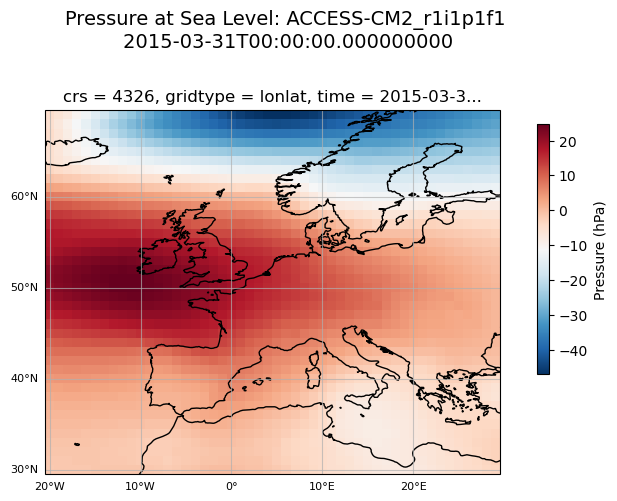

In [27]:
# Select a specific ESM run and one time step
tst = ts_datasets.sel(ESM_run='ACCESS-CM2_r1i1p1f1').isel(time=89)

# Compute vmin/vmax as Python floats
# vmin_da = tst['psl'].where(tst['psl'] > 0).min() / 100
vmin_da = tst['psl'].min() / 100

vmax_da = tst['psl'].max() / 100

# Force evaluation and extract a scalar
vmin = float(vmin_da.compute())
vmax = float(vmax_da.compute())

# Create a figure + Cartopy axis
fig, ax = plt.subplots(
    nrows=1, ncols=1,
    figsize=(6, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Shift longitudes from [0, 360] → [–180, +180], sort, convert units, and load
new_lon = ((tst.lon + 180) % 360) - 180
da2 = tst['psl'].assign_coords(lon=new_lon).sortby('lon') / 100
da2 = da2.load()  # now it’s a NumPy array under the hood

# Plot with plain‐float vmin/vmax
p = da2.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdBu_r',
    add_colorbar=False,
    vmin=vmin,
    vmax=vmax
)

ax.coastlines()
setup_gridlines(ax, deg=10, alpha=0.7)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])
plt.colorbar(p, cax=cbar_ax, label='Pressure (hPa)')

fig.suptitle(f'Pressure at Sea Level: ACCESS-CM2_r1i1p1f1\n {tst.time.values}', fontsize=14)
plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()
